# Tratamento dos dados

Dado que uma rede MLP espera como entrada um vetor unidimensional de características, é necessário adequar a representação das imagens da base de dados para esse formato.

Para isso, aplicaram-se as seguintes etapas de pré-processamento:

1. Conversão das imagens de RGB para escala de cinza, removendo os canais de cor e mantendo apenas a intensidade dos pixels, o que reduz a dimensionalidade dos dados.

2. *Flatten* das imagens para representação em linha, transformando a matriz bidimensional da imagem em um vetor unidimensional de características.

In [ ]:
# Imports

from keras.datasets import cifar10
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import set_random_seed, to_categorical
from keras.optimizers import Adam

set_random_seed(42)

In [2]:
# Carregamento dos dados

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print('Train Images Shape:      ', x_train.shape)
print('Train Labels Shape:      ', y_train.shape)

print('\nTest Images Shape:       ', x_test.shape)
print('Test Labels Shape:       ', y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step
Train Images Shape:       (50000, 32, 32, 3)
Train Labels Shape:       (50000, 1)

Test Images Shape:        (10000, 32, 32, 3)
Test Labels Shape:        (10000, 1)


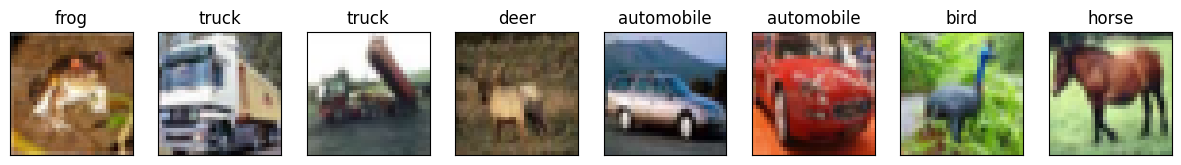

In [3]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 25 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train[i])

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [4]:
# Conversão das imagens de RGB para escala de cinza

# fórmula padrão: Y = 0.299 R + 0.587 G + 0.114 B
x_train_gray = np.dot(x_train[..., :3], [0.299, 0.587, 0.114])
x_test_gray = np.dot(x_test[..., :3], [0.299, 0.587, 0.114])

print('Train Images Shape (Gray scale):      ', x_train_gray.shape)
print('Test Images Shape (Gray scale):       ', x_test_gray.shape)

Train Images Shape (Gray scale):       (50000, 32, 32)
Test Images Shape (Gray scale):        (10000, 32, 32)


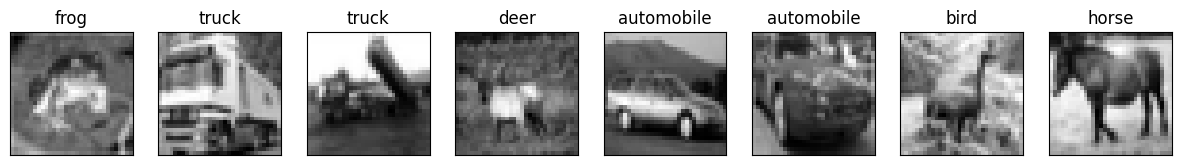

In [5]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 25 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train_gray[i], cmap='gray')

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [6]:
# Flatten das imagens e normalização [0, 1] (melhora estabilidade e acurácia)

x_train_flat = x_train_gray.reshape(x_train_gray.shape[0], -1).astype('float32') / 255.0
x_test_flat = x_test_gray.reshape(x_test_gray.shape[0], -1).astype('float32') / 255.0
x_train_df = pd.DataFrame(x_train_flat)
x_test_df = pd.DataFrame(x_test_flat)

print('Train Images Shape (Gray scale & Flatten):      ', x_train_df.shape)
print('Test Images Shape (Gray scale & Flatten):       ', x_test_df.shape)

Train Images Shape (Gray scale & Flatten):       (50000, 1024)
Test Images Shape (Gray scale & Flatten):        (10000, 1024)


# Estrutura da rede

In [ ]:
# Hiper-parâmetros
input_shape = 1024
epochs = 20
batch_size = 128
dropout_rate = 0.2
learning_rate = 0.001

In [ ]:
# Construção dos modelos da rede
model_1 = Sequential([
    Dense(256, activation='relu', input_shape=(input_shape,)),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax'),
])
model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,762 (1.26 MB)

 Trainable params: 330,762 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

# Experimento 1 — hiper-parâmetros da célula acima (dropout + Adam com lr fixo), sem early stop

In [24]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

model_1.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_1 = model_1.fit(
    x_train_df.values,
    y_train_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1,
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2613 - loss: 2.0367 - val_accuracy: 0.2958 - val_loss: 1.9525
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3257 - loss: 1.8892 - val_accuracy: 0.3328 - val_loss: 1.8709
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3506 - loss: 1.8270 - val_accuracy: 0.3580 - val_loss: 1.8137
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3678 - loss: 1.7797 - val_accuracy: 0.3692 - val_loss: 1.7731
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3828 - loss: 1.7393 - val_accuracy: 0.3858 - val_loss: 1.7440
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3943 - loss: 1.7063 - val_accuracy: 0.3900 - val_loss: 1.7283
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4054 - loss: 1.6769 - val_accuracy: 0.3968 - val_loss: 1.7063
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4137 - loss: 1.6504 - val_accurac

Modelo 1 Teste — loss: 1.6649, acurácia: 0.4157


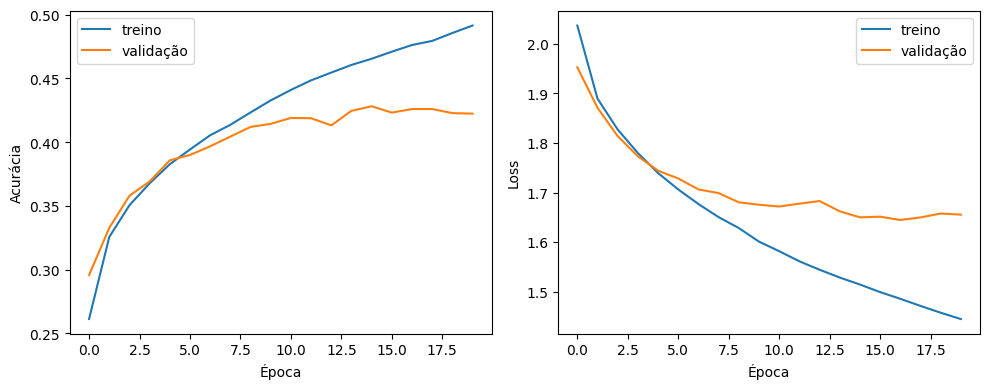

In [25]:
loss_1, acc_1 = model_1.evaluate(x_test_df.values, y_test_cat, verbose=0)
print(f'Modelo 1 Teste — loss: {loss_1:.4f}, acurácia: {acc_1:.4f}')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='treino')
plt.plot(history_1.history['val_accuracy'], label='validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='treino')
plt.plot(history_1.history['val_loss'], label='validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Principal motivo observado para a val_accuracy não melhorar muito durante os testes

**Um MLP simples não extrai bem características de imagens**

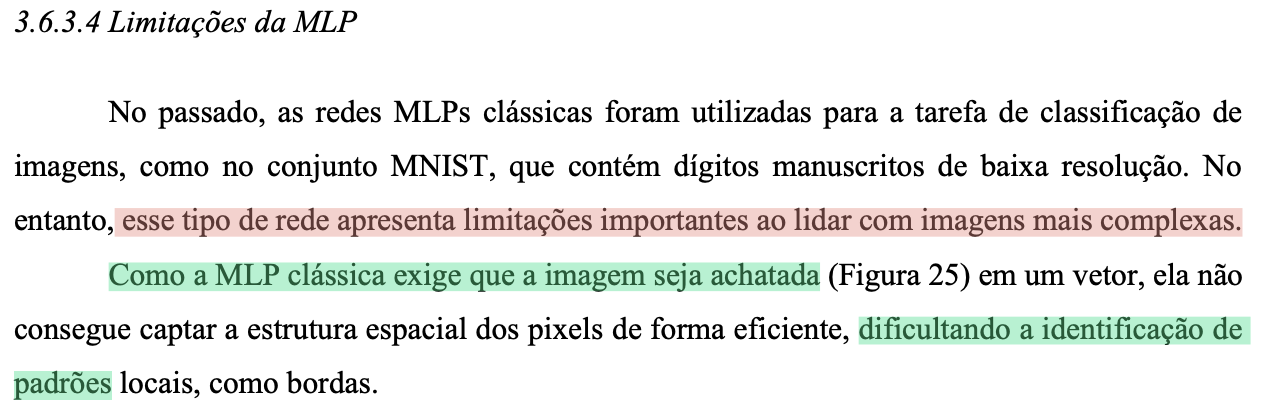

# Experimento 2 - Sem dropout e com early stop

In [10]:
# Treinamento

In [11]:
# Resutados

# Experimento 3 - Com dropout e sem early stop

In [12]:
# Treinamento

In [13]:
# Resultados

# Experimento 4 - Com dropout e com early stop

In [14]:
# Treinamento

In [15]:
# Resultados